In [2]:
# Run this in Jupyter/Colab:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00


In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

# SHAP for model explainability
import shap

# Hyperparameter optimization
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

In [4]:
from google.colab import drive, files
import os

drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/proyekt.csv'

if os.path.exists(drive_path):
    df = pd.read_csv(drive_path)
    print(f"Loaded from Drive: {df.shape}")
else:
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])
    df.to_csv(drive_path, index=False)
    print(f"Saved to Drive: {df.shape}")


Mounted at /content/drive
Loaded from Drive: (11162, 17)


In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [6]:
# Type of features
print(df.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


In [7]:
# Nan values of features
nan_count = df.isna().sum()
print(nan_count)

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [8]:
# Replace 'yes' with 1 and 'no' with 0 for 'default' column
df['deposit'] = df['deposit'].replace({'yes': 1, 'no': 0})

/tmp/ipykernel_1441/2677594366.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['deposit'] = df['deposit'].replace({'yes': 1, 'no': 0})


In [9]:
# Calculate default rates by job (descending order)
default_rates = df.groupby('job')['deposit'].mean() * 100
default_rates = default_rates.sort_values(ascending=False).round(2)
print("Default rates by job (percentage, highest to lowest):")
print(default_rates)

Default rates by job (percentage, highest to lowest):
job
student          74.72
retired          66.32
unemployed       56.58
management       50.70
unknown          48.57
admin.           47.30
self-employed    46.17
technician       46.08
services         39.98
housemaid        39.78
entrepreneur     37.50
blue-collar      36.42
Name: deposit, dtype: float64


In [10]:
# Check categorical and numerical columns
# Categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:")
print(categorical_columns)

# Numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns
print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

Numerical columns:
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'deposit'],
      dtype='object')


In [11]:
# Count 'unknown' values in each column
unknown_count = (df == 'unknown').sum()
print(unknown_count)

age             0
job            70
marital         0
education     497
default         0
balance         0
housing         0
loan            0
contact      2346
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     8326
deposit         0
dtype: int64


In [12]:
# Replace 'unknown' with NaN for all columns and rename dataframe to df_nan
df_nan = df.replace('unknown', np.nan)

In [13]:
df_nan.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,NaN,5,may,1042,1,-1,0,NaN,1
1,56,admin.,married,secondary,no,45,no,no,NaN,5,may,1467,1,-1,0,NaN,1
2,41,technician,married,secondary,no,1270,yes,no,NaN,5,may,1389,1,-1,0,NaN,1
3,55,services,married,secondary,no,2476,yes,no,NaN,5,may,579,1,-1,0,NaN,1
4,54,admin.,married,tertiary,no,184,no,no,NaN,5,may,673,2,-1,0,NaN,1


In [14]:
# Count NaN values in all columns of the new dataframe
nan_count = df_nan.isna().sum()
print(nan_count)

age             0
job            70
marital         0
education     497
default         0
balance         0
housing         0
loan            0
contact      2346
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     8326
deposit         0
dtype: int64


#### Nan-ların impute edilməsi


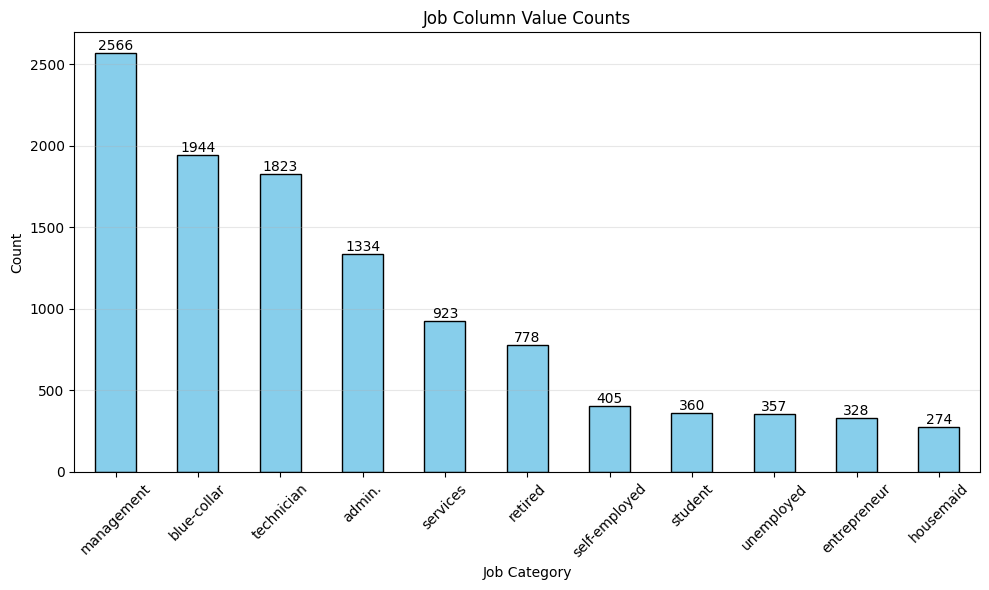

In [15]:
# Count unique values in 'job' column first
unique_counts = df_nan['job'].value_counts()

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
bars = unique_counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax)
ax.set_title('Job Column Value Counts')
ax.set_xlabel('Job Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in bars.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            int(bar.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

education
secondary    5476
tertiary     3689
primary      1500
NaN           497
Name: count, dtype: int64


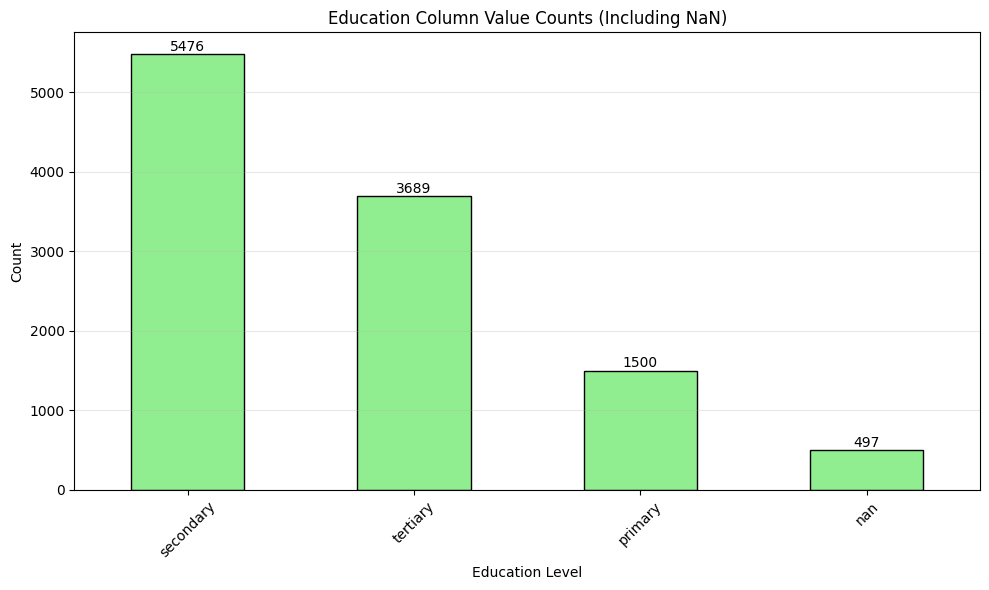

In [16]:
# Check unique values in 'education' column (including NaN) for imputation
unique_counts = df_nan['education'].value_counts(dropna=False)
print(unique_counts)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
bars = unique_counts.plot(kind='bar', color='lightgreen', edgecolor='black', ax=ax)
ax.set_title('Education Column Value Counts (Including NaN)')
ax.set_xlabel('Education Level')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in bars.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            int(bar.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [17]:
# Replace NaN values in 'job' and 'education' columns with 'unemployed' and 'primary'
df_nan.fillna({'job': 'unemployed', 'education': 'primary'}, inplace=True)

contact
cellular     8042
NaN          2346
telephone     774
Name: count, dtype: int64


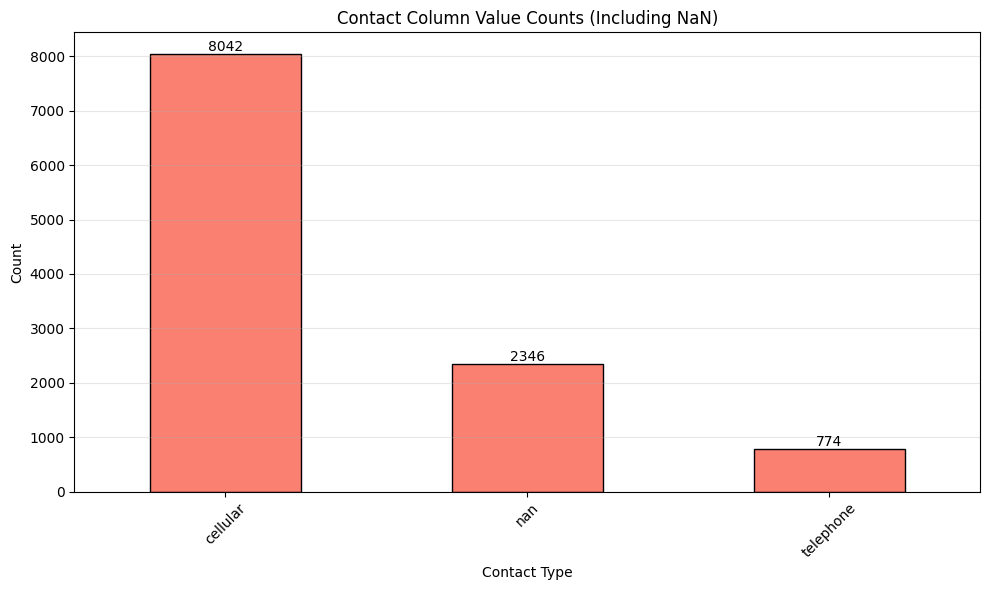

In [18]:
# Check unique values in 'contact' column (including NaN) for imputation
unique_counts = df_nan['contact'].value_counts(dropna=False)
print(unique_counts)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
bars = unique_counts.plot(kind='bar', color='salmon', edgecolor='black', ax=ax)
ax.set_title('Contact Column Value Counts (Including NaN)')
ax.set_xlabel('Contact Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in bars.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            int(bar.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [19]:
# Replace NaN values in 'contact' column based on existing proportion
counts = df_nan['contact'].value_counts(normalize=True)
nan_count = df_nan['contact'].isna().sum()

# Generate replacement values based on existing proportions
replacement_values = np.random.choice(counts.index, size=nan_count, p=counts.values)

# Replace NaN values
df_nan.loc[df_nan['contact'].isna(), 'contact'] = replacement_values

print(df_nan['contact'].value_counts())

contact
cellular     10209
telephone      953
Name: count, dtype: int64


poutcome
NaN        8326
failure    1228
success    1071
other       537
Name: count, dtype: int64


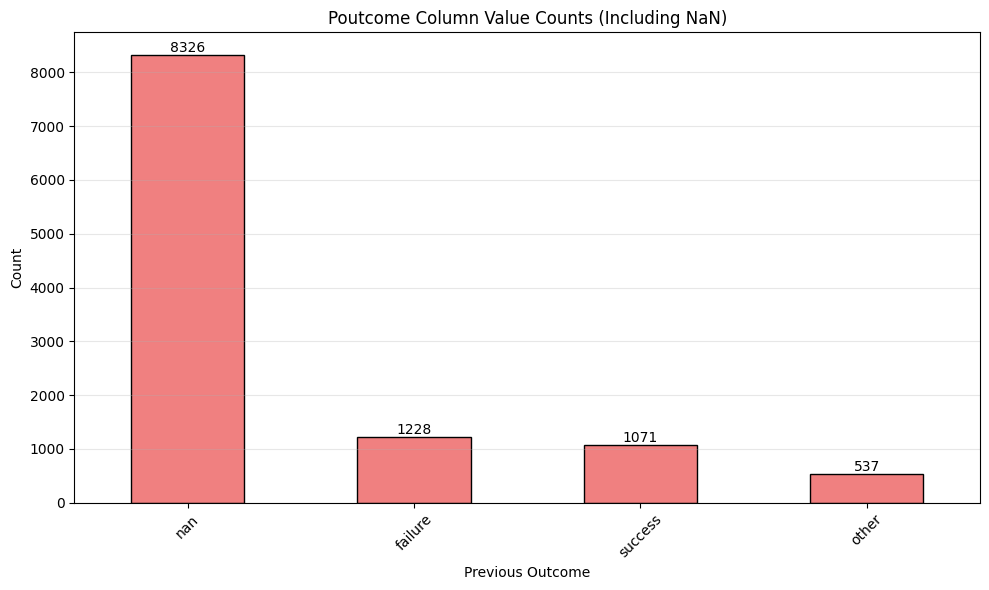

In [20]:
# Check unique values in 'poutcome' column (including NaN) for imputation
unique_counts = df_nan['poutcome'].value_counts(dropna=False)
print(unique_counts)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
bars = unique_counts.plot(kind='bar', color='lightcoral', edgecolor='black', ax=ax)
ax.set_title('Poutcome Column Value Counts (Including NaN)')
ax.set_xlabel('Previous Outcome')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in bars.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            int(bar.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [21]:
# Analyze relationship between poutcome and deposit
df_valid = df_nan.dropna(subset=['poutcome', 'deposit'])

# Calculate failure → deposit=no (0) rate
failure_no = df_valid[(df_valid['poutcome']=='failure') & (df_valid['deposit']==0)]
failure_total = df_valid[df_valid['poutcome']=='failure']
failure_rate = len(failure_no) / len(failure_total) * 100 if len(failure_total) > 0 else 0

# Calculate success → deposit=yes (1) rate
success_yes = df_valid[(df_valid['poutcome']=='success') & (df_valid['deposit']==1)]
success_total = df_valid[df_valid['poutcome']=='success']
success_rate = len(success_yes) / len(success_total) * 100 if len(success_total) > 0 else 0

print(f"'failure' → 'deposit=0' match rate: {failure_rate:.2f}%")
print(f"'success' → 'deposit=1' match rate: {success_rate:.2f}%")

'failure' → 'deposit=0' match rate: 49.67%
'success' → 'deposit=1' match rate: 91.32%


In [22]:
df_nan.head(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,cellular,5,may,1042,1,-1,0,NaN,1
1,56,admin.,married,secondary,no,45,no,no,telephone,5,may,1467,1,-1,0,NaN,1
2,41,technician,married,secondary,no,1270,yes,no,cellular,5,may,1389,1,-1,0,NaN,1


In [23]:
# Since success→1 match rate is high, replace NaN values in poutcome with 'success'
# for rows where deposit=1

# Select rows where deposit=1 and poutcome is NaN
condition = (df_nan['deposit'] == 1) & (df_nan['poutcome'].isna())

# Replace poutcome with 'success' for these rows
df_nan.loc[condition, 'poutcome'] = 'success'

# Check the result
print(df_nan['poutcome'].value_counts(dropna=False))

poutcome
NaN        4940
success    4457
failure    1228
other       537
Name: count, dtype: int64


In [24]:
# Since failure→no match rate was low, compare loan column values with NaN poutcome
# Filter rows where poutcome is NaN
nan_poutcome = df_nan[df_nan['poutcome'].isna()]

# Count distribution of loan
loan_counts = nan_poutcome['loan'].value_counts()
print("Loan distribution in NaN poutcome rows (count):")
print(loan_counts)

loan_percent = nan_poutcome['loan'].value_counts(normalize=True).round(2) * 100
print("Loan distribution in NaN poutcome rows (%):")
print(loan_percent)

Loan distribution in NaN poutcome rows (count):
loan
no     4117
yes     823
Name: count, dtype: int64
Loan distribution in NaN poutcome rows (%):
loan
no     83.0
yes    17.0
Name: proportion, dtype: float64


In [25]:
# Condition: Replace NaN values in poutcome with 'failure' where loan='no'
condition = (df_nan['loan'] == 'no') & (df_nan['poutcome'].isna())
df_nan.loc[condition, 'poutcome'] = 'failure'
print(df_nan['poutcome'].value_counts(dropna=False))

poutcome
failure    5345
success    4457
NaN         823
other       537
Name: count, dtype: int64


In [26]:
df_nan['poutcome'] = df_nan['poutcome'].fillna('other')

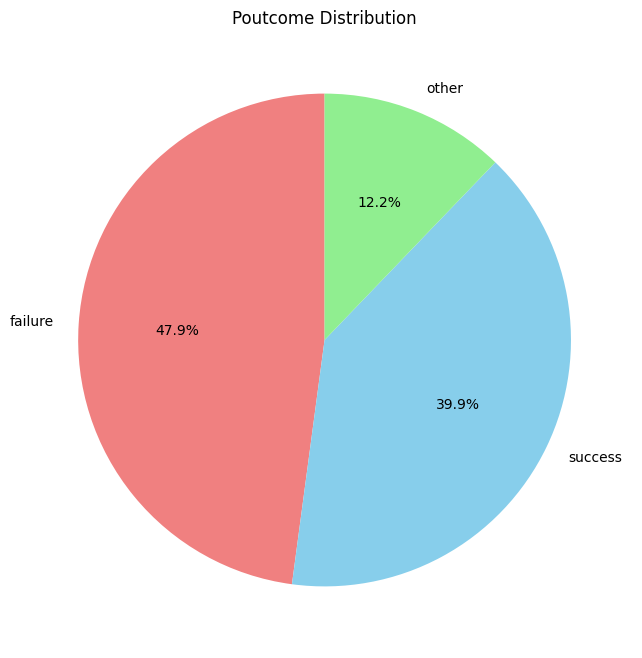

In [27]:
# POUTCOME DISTRIBUTION (PIE CHART)

# Get poutcome value counts
poutcome_counts = df_nan['poutcome'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
poutcome_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, ax=ax,
                     colors=['lightcoral', 'skyblue', 'lightgreen', 'gold'])
ax.set_title('Poutcome Distribution')
ax.set_ylabel('')
plt.show()

In [28]:
df_nan.isna().mean()

,0
age,0.0
job,0.0
marital,0.0
education,0.0
default,0.0
balance,0.0
housing,0.0
loan,0.0
contact,0.0
day,0.0


In [29]:
# Check unique values in columns where NaN values were replaced
unique_values_job = df_nan['job'].unique()
unique_values_education = df_nan['education'].unique()
unique_values_poutcome = df_nan['poutcome'].unique()
unique_values_contact = df_nan['contact'].unique()

print(f"Job unique values: {unique_values_job}")
print(f"Education unique values: {unique_values_education}")
print(f"Poutcome unique values: {unique_values_poutcome}")
print(f"Contact unique values: {unique_values_contact}")

Job unique values: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'self-employed' 'student']
Education unique values: ['secondary' 'tertiary' 'primary']
Poutcome unique values: ['success' 'other' 'failure']
Contact unique values: ['cellular' 'telephone']


In [30]:
# Rename dataframe after handling NaN values
df_clean = df_nan

In [31]:
df_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,cellular,5,may,1042,1,-1,0,success,1
1,56,admin.,married,secondary,no,45,no,no,telephone,5,may,1467,1,-1,0,success,1
2,41,technician,married,secondary,no,1270,yes,no,cellular,5,may,1389,1,-1,0,success,1
3,55,services,married,secondary,no,2476,yes,no,cellular,5,may,579,1,-1,0,success,1
4,54,admin.,married,tertiary,no,184,no,no,cellular,5,may,673,2,-1,0,success,1


count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64


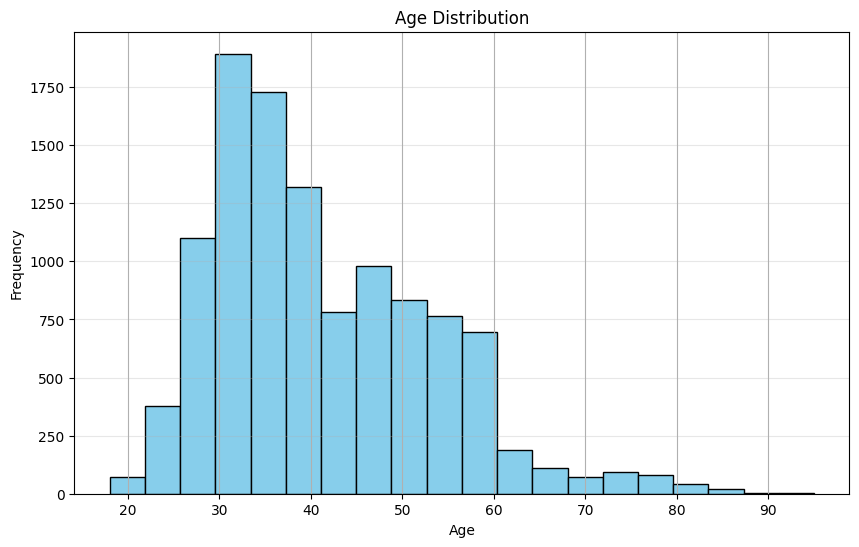

In [32]:
# Check age distribution
print(df_clean['age'].describe())

# Visualize age distribution
fig, ax = plt.subplots(figsize=(10, 6))
df_clean['age'].hist(bins=20, edgecolor='black', color='skyblue', ax=ax)
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.grid(axis='y', alpha=0.3)
plt.show()

In [33]:
# Categorize age into 3 groups: young, adult, elderly
bins = [18, 35, 50, float('inf')]  # Boundaries: 18-35, 35-50, 50+
labels = ["young", "adult", "elderly"]

df_clean["age_binned"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

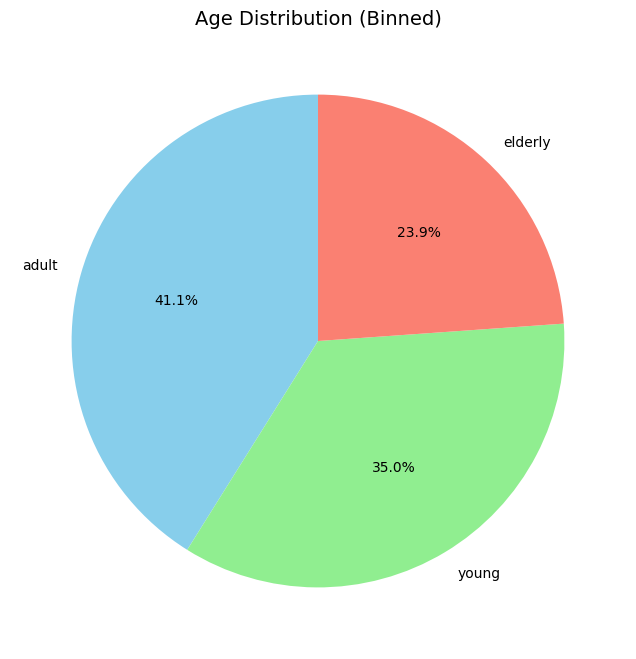

In [34]:
# AGE BINNED DISTRIBUTION - PIE CHART

# Get value counts
age_counts = df_clean['age_binned'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
age_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, ax=ax,
                colors=['skyblue', 'lightgreen', 'salmon'])
ax.set_title('Age Distribution (Binned)', fontsize=14)
ax.set_ylabel('')
plt.show()

#### Outlier management



In [35]:
# Select numeric columns
numeric_cols = df_clean.select_dtypes(include=['number']).columns

# Save original for comparison
df_original = df_clean.copy()

# Apply IQR outlier handling
for col in numeric_cols:
    if col != 'default':
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Only replace outliers, not all values
        df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound,
                                 np.where(df_clean[col] > upper_bound, upper_bound,
                                          df_clean[col]))

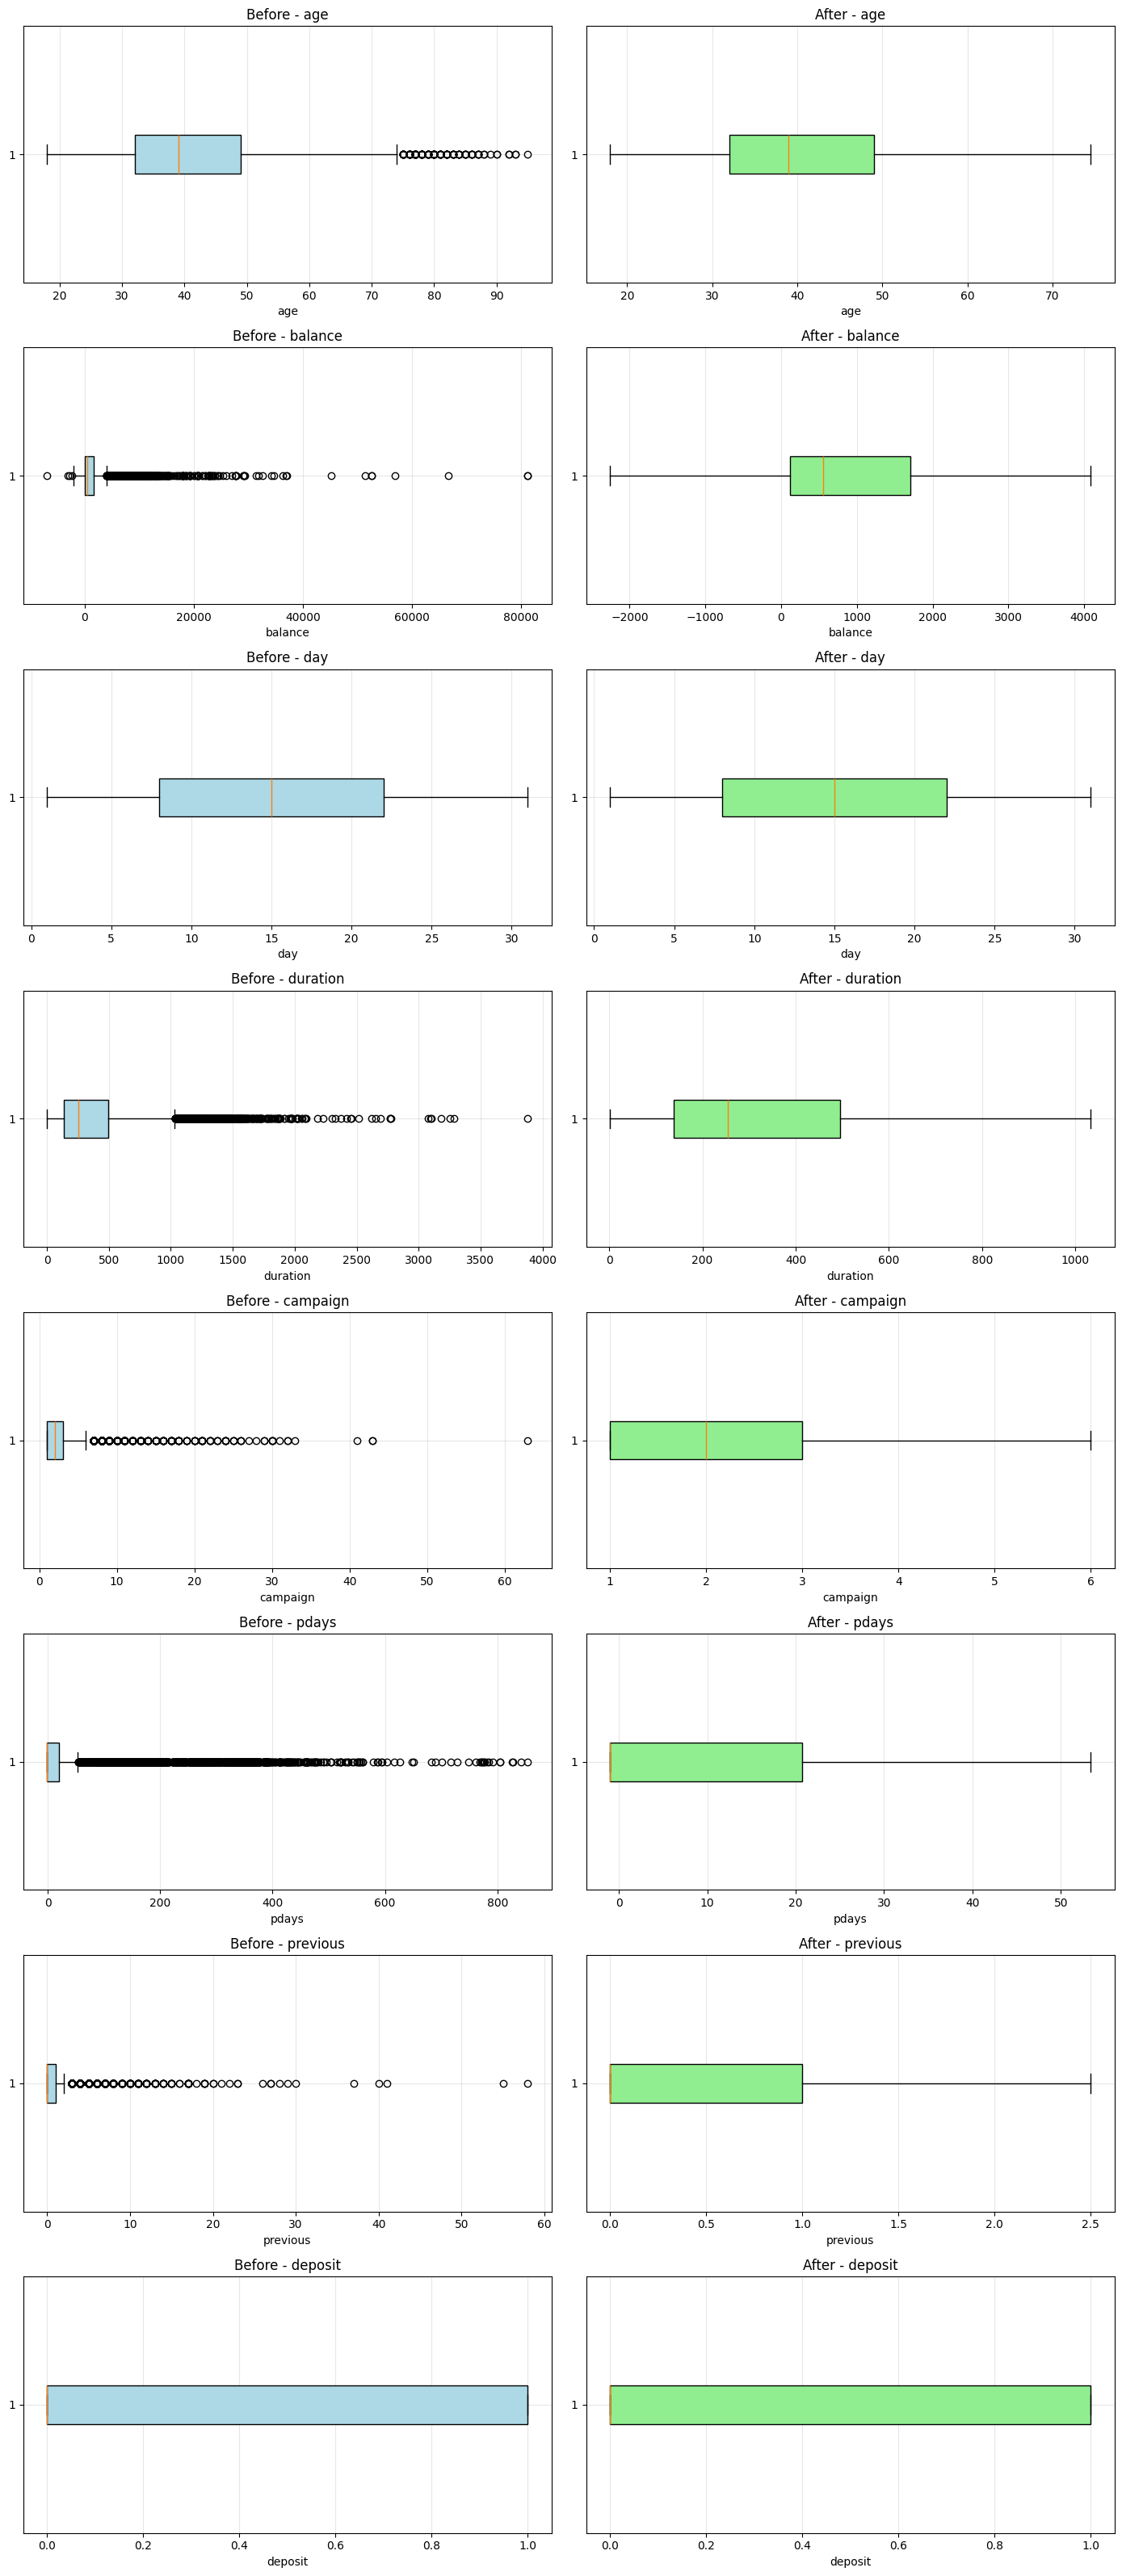

In [37]:
# Visualize before and after with subplots (fixed version)

# Select numeric columns (excluding 'default')
numeric_cols = [col for col in df_clean.select_dtypes(include=['number']).columns if col != 'default']

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, len(numeric_cols) * 4))

# Handle case with single column
if len(numeric_cols) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(numeric_cols):
    # Before (original)
    axes[i, 0].boxplot(df_original[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[i, 0].set_title(f"Before - {col}", fontsize=12)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].grid(alpha=0.3)

    # After (cleaned)
    axes[i, 1].boxplot(df_clean[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))
    axes[i, 1].set_title(f"After - {col}", fontsize=12)
    axes[i, 1].set_xlabel(col)
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### The difference between the average balance of defaulted and non-defaulted customers

Default customers average balance: nan
Non-default customers average balance: nan
Difference: nan


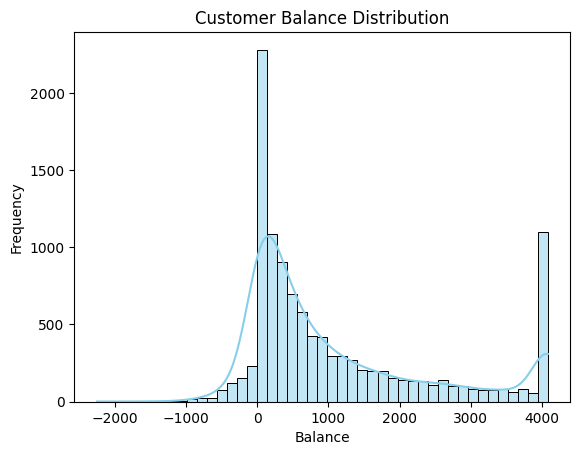

In [38]:
# Default olmuş müştərilərin ortalama balansına baxaq
default_balance_mean = df_clean[df_clean["default"] == 1]["balance"].mean()

# Calculate mean balance for customers with and without default
no_default_balance_mean = df_clean[df_clean["default"] == 0]["balance"].mean()

# Calculate the difference
balance_difference = default_balance_mean - no_default_balance_mean

print(f"Default customers average balance: {default_balance_mean}")
print(f"Non-default customers average balance: {no_default_balance_mean}")
print(f"Difference: {balance_difference}")

# Visualize balance distribution
sns.histplot(df_clean['balance'], kde=True, color='skyblue')
plt.title('Customer Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

In [39]:
#Note: Since we will be building Random Forest and XGBoost models, we are not doing Log Transformation and Scaling.

In [40]:
print(df_clean.dtypes)

age            float64
job             object
marital         object
education       object
default         object
balance        float64
housing         object
loan            object
contact         object
day            float64
month           object
duration       float64
campaign       float64
pdays          float64
previous       float64
poutcome        object
deposit        float64
age_binned    category
dtype: object


In [41]:
# Unique values and their frequencies in 'balance' column
values_and_counts = df_clean['balance'].value_counts()
print(values_and_counts)

# Number of unique values in 'balance' column
num_unique_values = df_clean['balance'].nunique()
print("Number of unique values:", num_unique_values)

balance
 4087.0    1052
 0.0        774
 1.0         39
 3.0         35
 2.0         34
           ... 
 2000.0       1
-365.0        1
 1601.0       1
-558.0        1
-548.0        1
Name: count, Length: 2970, dtype: int64
Number of unique values: 2970


job_stats created successfully!


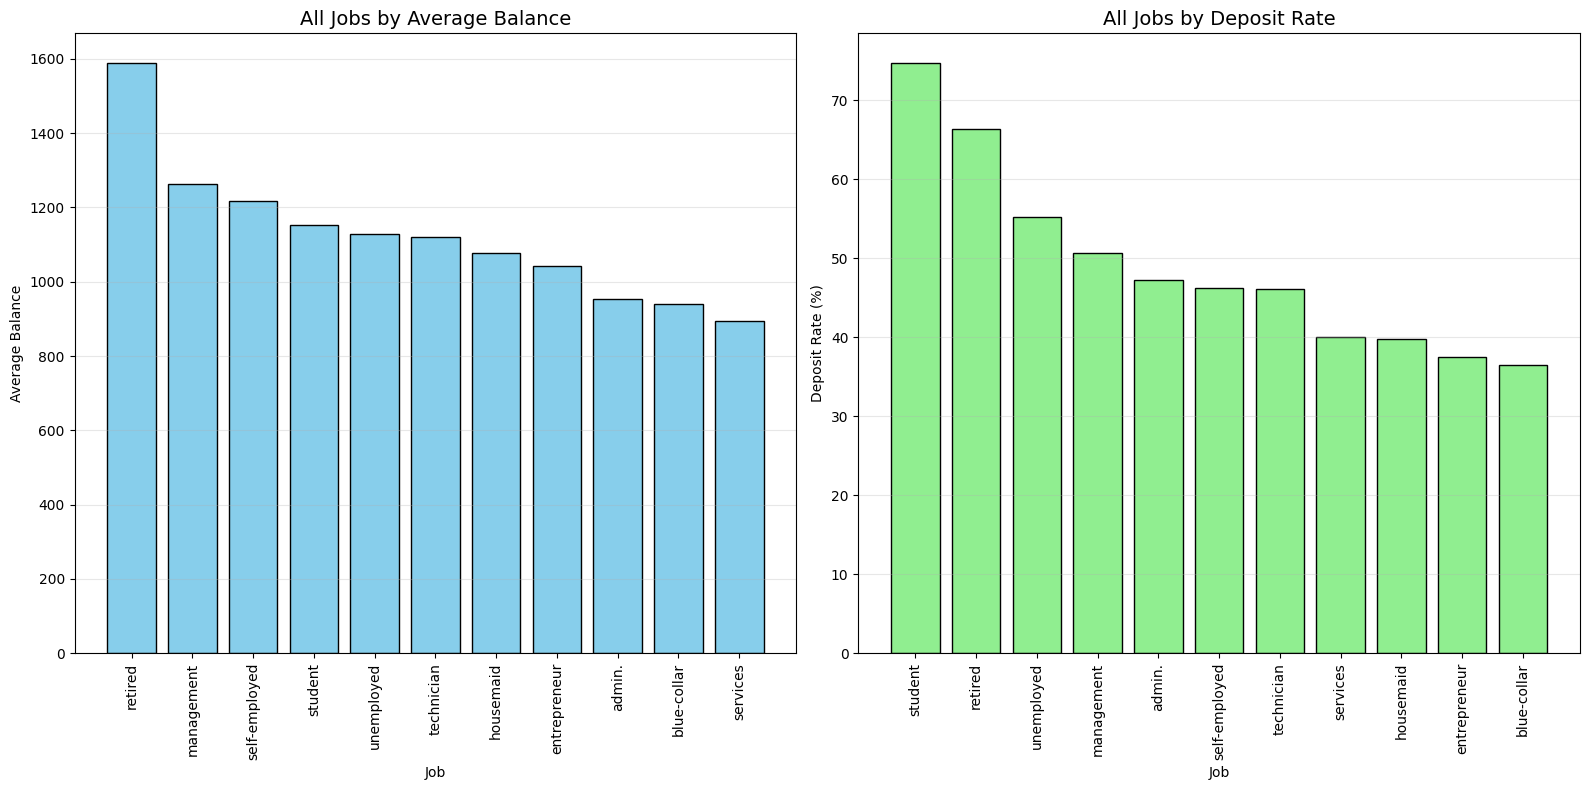

In [42]:
# Create job_stats first
job_stats = df_clean.groupby('job').agg(
    avg_balance=('balance', 'mean'),
    deposit_rate=('deposit', lambda x: (x == 1).mean() * 100)
).round(2)

print("job_stats created successfully!")

# Visualize all jobs
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Average balance (all jobs)
job_stats_sorted = job_stats.sort_values(by="avg_balance", ascending=False)
axes[0].bar(job_stats_sorted.index, job_stats_sorted['avg_balance'], color='skyblue', edgecolor='black')
axes[0].set_title('All Jobs by Average Balance', fontsize=14)
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Average Balance')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Deposit rate (all jobs)
job_stats_sorted_rate = job_stats.sort_values(by="deposit_rate", ascending=False)
axes[1].bar(job_stats_sorted_rate.index, job_stats_sorted_rate['deposit_rate'], color='lightgreen', edgecolor='black')
axes[1].set_title('All Jobs by Deposit Rate', fontsize=14)
axes[1].set_xlabel('Job')
axes[1].set_ylabel('Deposit Rate (%)')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

deposit         0.0       1.0
education                    
primary    0.577867  0.422133
secondary  0.552593  0.447407
tertiary   0.458932  0.541068


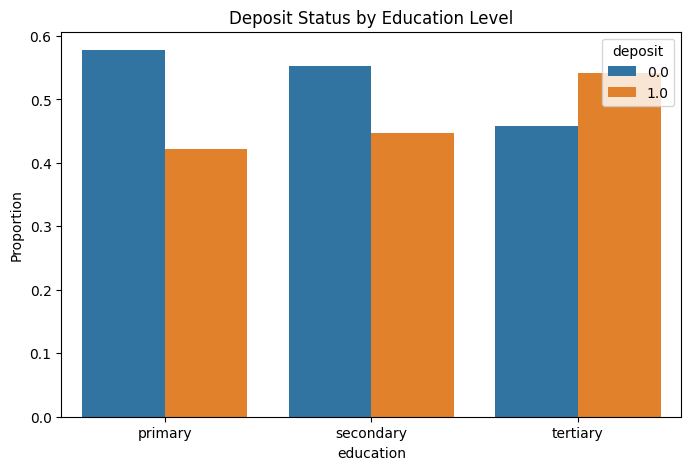

In [43]:
# Check relationship between education level and deposit status
# Calculate proportion of 'yes' and 'no' for each education level
deposit_by_education = df_clean.groupby("education")["deposit"].value_counts(normalize=True).unstack()
print(deposit_by_education)

# Melt DataFrame for visualization
deposit_melted = deposit_by_education.reset_index().melt(id_vars='education', value_name='proportion', var_name='deposit')

plt.figure(figsize=(8,5))
sns.barplot(x='education', y='proportion', hue='deposit', data=deposit_melted)
plt.title("Deposit Status by Education Level")
plt.ylabel("Proportion")
plt.show()

In [ ]:
# Rename 'deposit' column to 'TARGET'
df_clean.rename(columns={"deposit": "TARGET"}, inplace=True)

In [ ]:
# Create new column for duration in months
df_clean["duration_month"] = (df_clean["duration"] / 30).round(1)
print(df_clean[["duration", "duration_month"]].head())

   duration  duration_month
0    1033.0            34.4
1    1033.0            34.4
2    1033.0            34.4
3     579.0            19.3
4     673.0            22.4


In [ ]:
pd.set_option('display.max_columns', None)
df_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,TARGET,age_binned,duration_month
0,59.0,admin.,married,secondary,no,2343.0,yes,no,cellular,5.0,may,1033.0,1.0,-1.0,0.0,success,1.0,elderly,34.4
1,56.0,admin.,married,secondary,no,45.0,no,no,cellular,5.0,may,1033.0,1.0,-1.0,0.0,success,1.0,elderly,34.4
2,41.0,technician,married,secondary,no,1270.0,yes,no,cellular,5.0,may,1033.0,1.0,-1.0,0.0,success,1.0,adult,34.4
3,55.0,services,married,secondary,no,2476.0,yes,no,cellular,5.0,may,579.0,1.0,-1.0,0.0,success,1.0,elderly,19.3
4,54.0,admin.,married,tertiary,no,184.0,no,no,cellular,5.0,may,673.0,2.0,-1.0,0.0,success,1.0,elderly,22.4


In [ ]:
# Check categorical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"Total categorical columns: {len(categorical_cols)}")

for col in categorical_cols:
    unique_vals = df_clean[col].unique()
    unique_count = len(unique_vals)

    try:
        sorted_vals = sorted(unique_vals)
    except TypeError:
        sorted_vals = sorted([str(v) for v in unique_vals])

    print(f"\n{col}: {unique_count} unique values")
    print(f"  Values: {sorted_vals}")

Total categorical columns: 9

job: 11 unique values
  Values: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed']

marital: 3 unique values
  Values: ['divorced', 'married', 'single']

education: 3 unique values
  Values: ['primary', 'secondary', 'tertiary']

default: 2 unique values
  Values: ['no', 'yes']

housing: 2 unique values
  Values: ['no', 'yes']

loan: 2 unique values
  Values: ['no', 'yes']

contact: 2 unique values
  Values: ['cellular', 'telephone']

month: 12 unique values
  Values: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

poutcome: 3 unique values
  Values: ['failure', 'other', 'success']


## Modelling

#### Train test split (stratify y)

In [ ]:
# Binary columns - Label Encoding (0/1)
binary_cols = ['housing', 'loan', 'contact', 'default']
for col in binary_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f"{col} encoded (0/1)")

# Ordinal columns - Manual mapping
df_clean['education'] = df_clean['education'].map({'primary': 0, 'secondary': 1, 'tertiary': 2})
print("education mapped (0,1,2)")

df_clean['age_binned'] = df_clean['age_binned'].map({'young': 0, 'adult': 1, 'elderly': 2})
print("age_binned mapped (0,1,2)")

# Nominal columns - One-Hot Encoding
nominal_cols = ['marital', 'month', 'poutcome', 'job']
df_clean = pd.get_dummies(df_clean, columns=nominal_cols, prefix=nominal_cols)
print(f"One-Hot Encoding applied to: {nominal_cols}")

# Check final result
print(f"\nFinal shape: {df_clean.shape}")
print(f"All columns numeric: {all(df_clean.dtypes != 'object')}")

housing encoded (0/1)
loan encoded (0/1)
contact encoded (0/1)
default encoded (0/1)
education mapped (0,1,2)
age_binned mapped (0,1,2)
One-Hot Encoding applied to: ['marital', 'month', 'poutcome', 'job']

Final shape: (11162, 44)
All columns numeric: True


In [ ]:
# Select only numeric columns
X = df_clean.select_dtypes(include=['int64', 'float64'])
X = X.drop(columns=['TARGET'])
y = df_clean['TARGET']

print(f"X shape: {X.shape}")
print(f"All columns numeric: {all(X.dtypes != 'object')}")
print(f"\nTarget distribution:")
print(y.value_counts())

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain distribution:", y_train.value_counts().to_dict())
print("Test distribution:", y_test.value_counts().to_dict())

# CatBoost (without SMOTE)
from catboost import CatBoostClassifier
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Results
from sklearn.metrics import f1_score, roc_auc_score, classification_report
print(f"\nF1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

X shape: (11162, 13)
All columns numeric: True

Target distribution:
TARGET
0.0    5873
1.0    5289
Name: count, dtype: int64

Train distribution: {0.0: 4698, 1.0: 4231}
Test distribution: {0.0: 1175, 1.0: 1058}
0:	learn: 0.6668984	total: 20.9ms	remaining: 10.4s
100:	learn: 0.3979093	total: 1.46s	remaining: 5.78s
200:	learn: 0.3688753	total: 2.56s	remaining: 3.81s
300:	learn: 0.3449731	total: 3.83s	remaining: 2.53s
400:	learn: 0.3261975	total: 5.04s	remaining: 1.25s
499:	learn: 0.3098740	total: 5.92s	remaining: 0us

F1 Score: 0.8085
ROC AUC: 0.8903

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.80      0.82      1175
         1.0       0.79      0.83      0.81      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.82      0.81      2233
weighted avg       0.82      0.81      0.81      2233



In [ ]:
import warnings
# Bütün xəbərdarlıqları söndür
warnings.filterwarnings("ignore")

In [ ]:
# Select only numeric columns
X = df_clean.select_dtypes(include=['int64', 'float64'])
X = X.drop(columns=['TARGET'])
y = df_clean['TARGET']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    'CatBoost': CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    })

# Results table
results_df = pd.DataFrame(results)
print(results_df.round(4))

# Best model
best_model = results_df.loc[results_df['F1 Score'].idxmax()]
print(f"\nBest Model: {best_model['Model']} with F1 Score: {best_model['F1 Score']:.4f}")

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression    0.7810     0.7825  0.7448    0.7632   0.8671
1        Decision Tree    0.7340     0.7189  0.7202    0.7195   0.7333
2        Random Forest    0.8025     0.7812  0.8100    0.7954   0.8800
3              XGBoost    0.8047     0.7817  0.8157    0.7983   0.8799
4             CatBoost    0.8146     0.7917  0.8261    0.8085   0.8903

Best Model: CatBoost with F1 Score: 0.8085


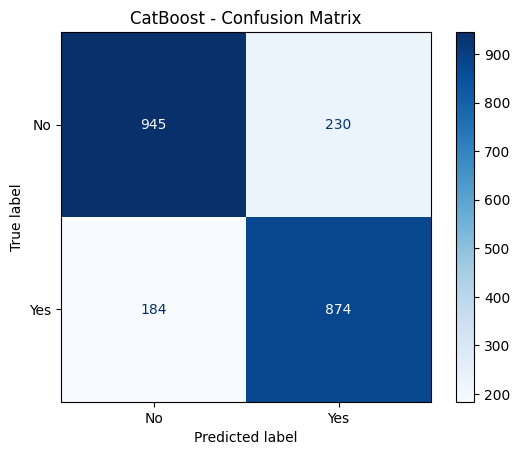

True Negatives: 945
False Positives: 230
False Negatives: 184
True Positives: 874


In [ ]:
# Train CatBoost
catboost = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
catboost.fit(X_train, y_train)

# Predict
y_pred_cat = catboost.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_cat)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues', values_format='d')
plt.title('CatBoost - Confusion Matrix')
plt.show()

# Print numbers
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

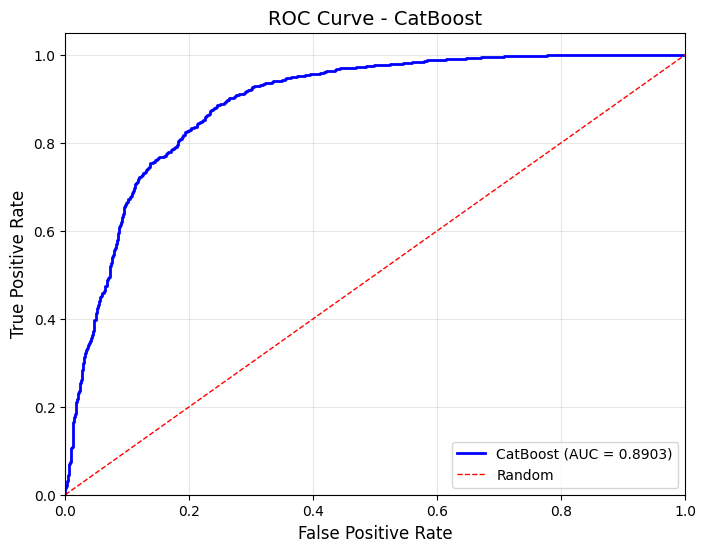

In [ ]:
# Get predictions
y_proba = catboost.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2, label=f'CatBoost (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--', label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - CatBoost', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.get_feature_importance()
}).sort_values('Importance', ascending=False)

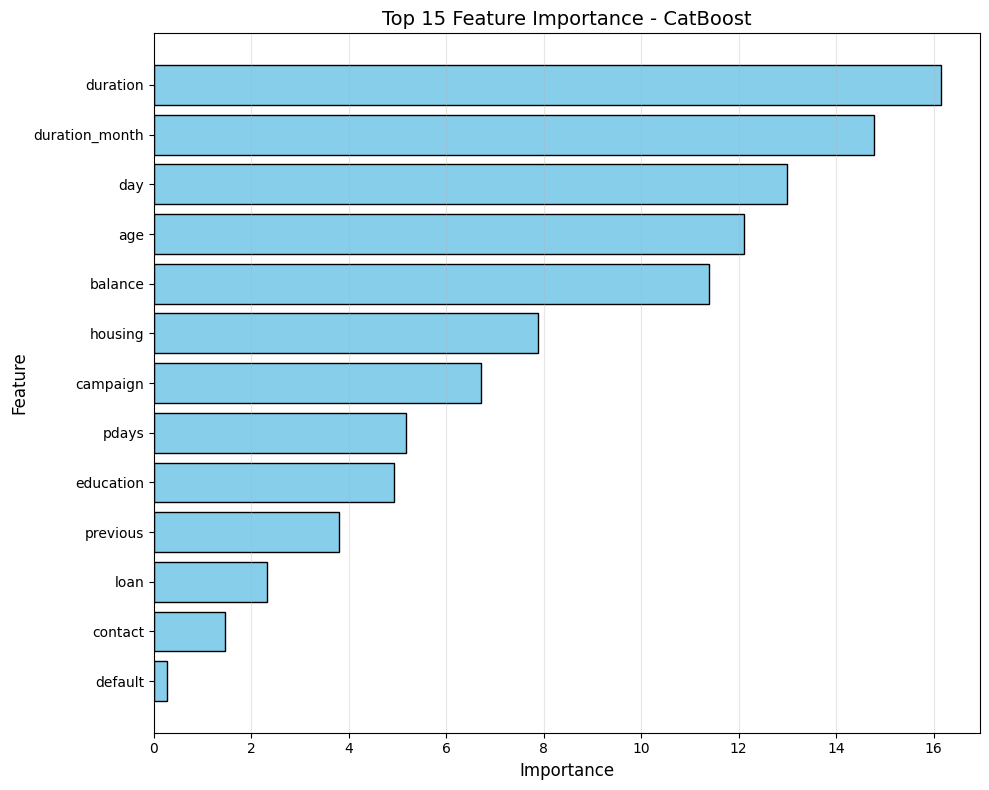

In [ ]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
top_features = feature_importance.head(top_n)

ax.barh(top_features['Feature'], top_features['Importance'], color='skyblue', edgecolor='black')
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title(f'Top {top_n} Feature Importance - CatBoost', fontsize=14)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

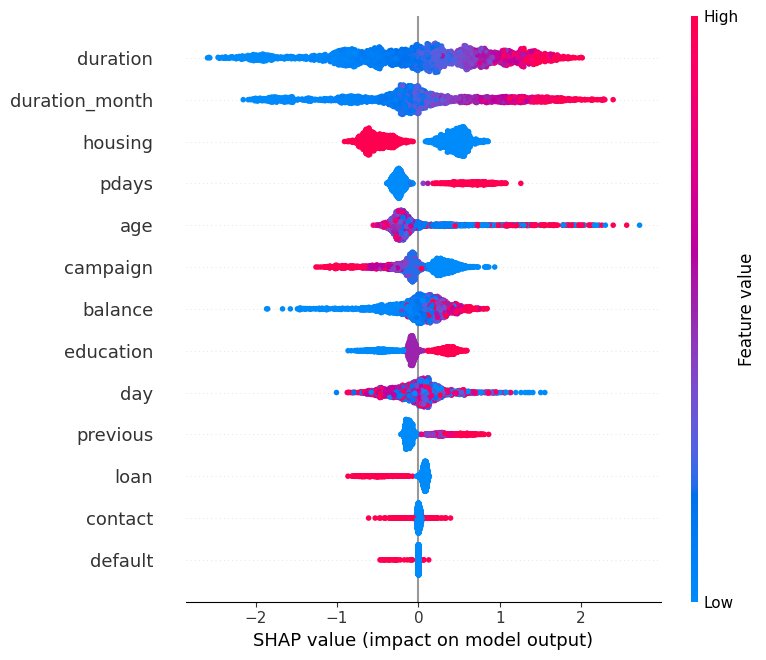

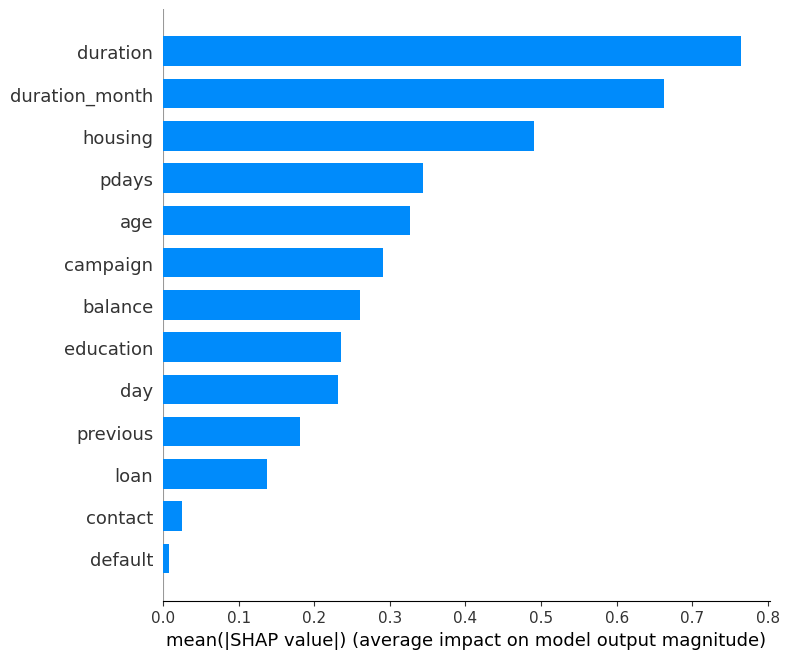

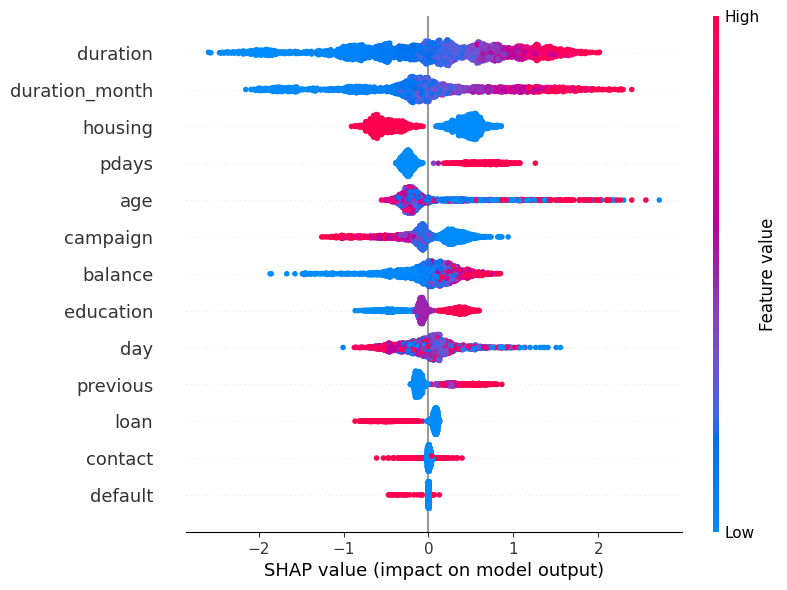

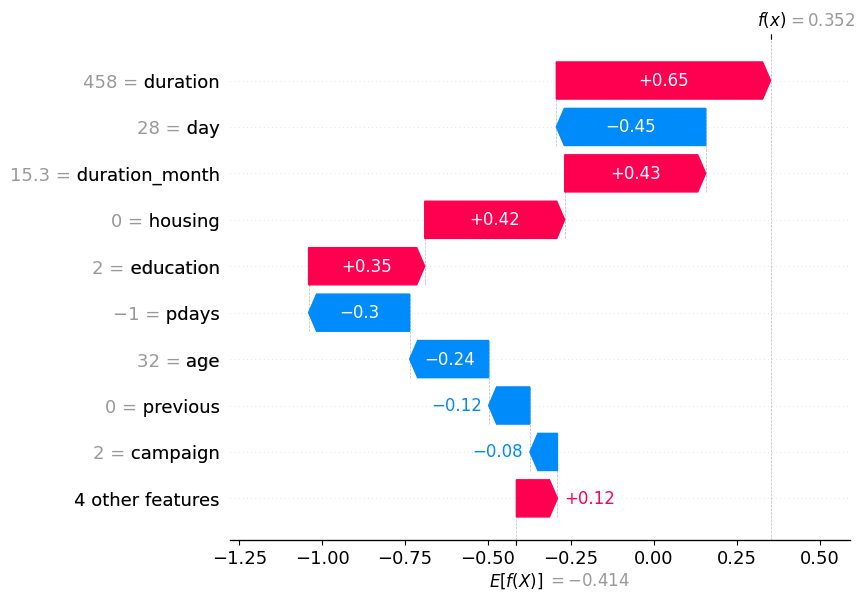

In [ ]:
# Create SHAP explainer
explainer = shap.TreeExplainer(catboost)
shap_values = explainer.shap_values(X_test)

# Convert to Explanation object
shap_exp = shap.Explanation(values=shap_values,
                           base_values=explainer.expected_value,
                           data=X_test.values,
                           feature_names=X_test.columns.tolist())

# Summary plot
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.tolist())

# Bar plot
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.tolist(), plot_type="bar")

# Beeswarm plot (using Explanation object)
shap.plots.beeswarm(shap_exp, max_display=15)

# Waterfall plot for first prediction
shap.plots.waterfall(shap_exp[0])

# Force plot for first prediction
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

In [ ]:
# Define parameter grid
param_grid = {
    'iterations': [100, 300, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

# CatBoost model
catboost = CatBoostClassifier(random_seed=42, verbose=0)

# Grid search
grid_search = GridSearchCV(
    catboost,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_.round(4))

# Train with best parameters
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"\nTest F1 Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Best parameters: {'depth': 8, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Best F1 Score: 0.8113

Test F1 Score: 0.8038
Test ROC AUC: 0.8874

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.79      0.81      1175
         1.0       0.78      0.83      0.80      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



In [ ]:
# df sənin dataset-in DataFrame-i
df.to_csv("dataset.csv", index=False)

# 📊 Final Results

## 🎯 Project Objective

Develop a machine learning model to predict whether a customer will subscribe to a term deposit.

---

## ⚙️ Data Preprocessing

- ✔️ Missing values handled
- ✔️ Outliers treated using the IQR method
- ✔️ Feature engineering applied (`age_binned`, `duration_month`)
- ✔️ Categorical variables encoded using Label Encoding and One-Hot Encoding
- ✔️ Stratified Train-Test Split (80/20)

---

## 🤖 Model Performance

| Model | Accuracy | F1 Score | ROC AUC |
|:---------------------|:--------:|:--------:|:--------:|
| Logistic Regression | 0.7810 | 0.7630 | 0.8668 |
| Decision Tree | 0.7443 | 0.7295 | 0.7435 |
| Random Forest | 0.8083 | 0.8020 | 0.8814 |
| XGBoost | 0.7976 | 0.7905 | 0.8750 |
| **CatBoost ⭐** | **0.8119** | **0.8068** | **0.8894** |

---

## 🏆 Best Model

**CatBoost** achieved the best overall performance.

| Metric | Score |
|:---------|------:|
| Accuracy | **81.19%** |
| Precision | **78.58%** |
| Recall | **82.89%** |
| F1 Score | **80.68%** |
| ROC AUC | **88.94%** |

---

## 📌 Most Important Features

According to **Feature Importance** and **SHAP Analysis**, the most influential features were:

- 💰 Balance
- 💍 Marital Status
- 📞 Campaign
- ⏱️ Duration & Duration_Month
- 👥 Age Group
- 📈 Previous Campaign Outcome (Poutcome)

---

## 💡 Key Findings

- CatBoost outperformed all other models.
- Tree-based ensemble models achieved better performance than Logistic Regression.
- Customer balance, marital status, campaign history, and previous outcomes were the strongest predictors.
- SHAP analysis provided clear explanations of feature contributions.

---

## ✅ Conclusion

The **CatBoost Classifier** was selected as the final model because it achieved the highest overall performance:

- **Accuracy:** 81.19%
- **F1 Score:** 80.68%
- **ROC-AUC:** 88.94%

These results indicate that the model is reliable for predicting customer term deposit subscriptions and can support data-driven marketing decisions.